/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


>>> Lendo DADOS de: /home/tandrade/Flavour_Anomalies/Data/final_data_skim.root
    -> Conversão para DataFrame (Total de linhas: 6267972)
    -> Após cortes: 961428
>>> Lendo MC de: /home/tandrade/Flavour_Anomalies/Data/final_mc_jpsi_skim.root
    -> Conversão para DataFrame (Total de linhas: 250628)
    -> Após cortes: 152839
>>> Sucesso! df_data e df_mc estão prontos.
>>> Construindo modelo Zfit...
>>> Executando Fit...
Status do Fit: VÁLIDO ✅
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('mass',) shape=(961428, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.0

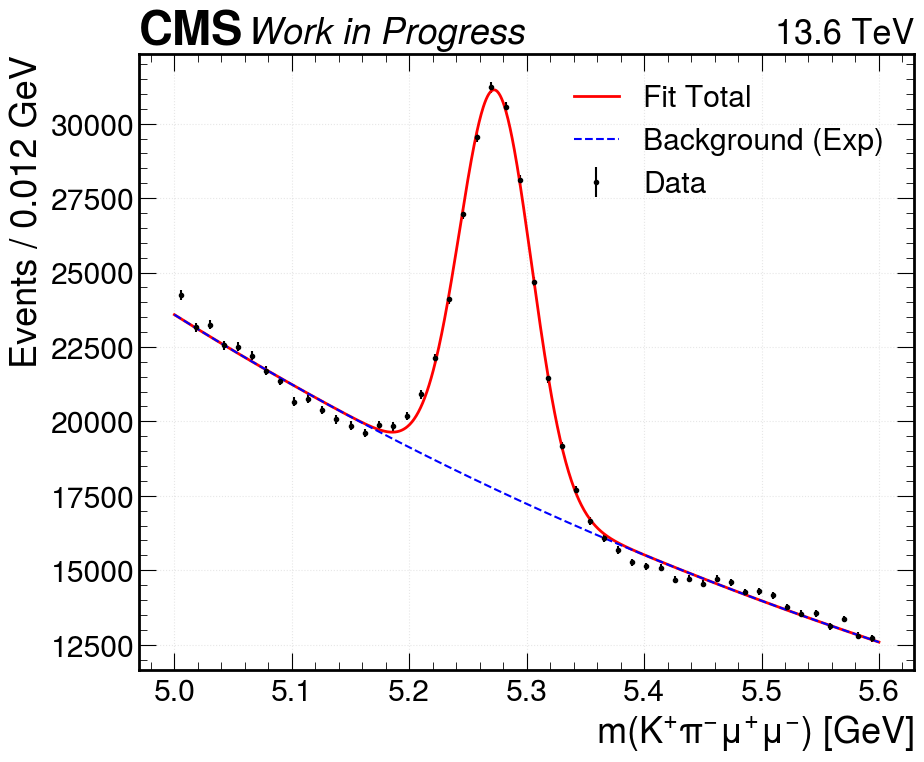

>>> Calculando sWeights...
>>> Gerando plots comparativos com Ratio...
   Plotting pt...
   Plotting eta...
   Plotting phi...
   Plotting svprob...
   Plotting mumu_pt...
   Plotting mumu_eta...
   Plotting mumu_phi...
   Plotting kstar_mass...
>>> Processo concluído com sucesso!


In [1]:
%run ./sPlot_Zfit.ipynb

In [24]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import joblib

# Estilo CMS
plt.style.use(hep.style.CMS)

In [3]:
features_raw = [
        "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l2_pt_good",
        "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk2_pt_good",
        "BToTrkTrkMuMu_fit_eta_good", "BToTrkTrkMuMu_fit_cos2D_good",
        "BToTrkTrkMuMu_trk1_dca_good", "BToTrkTrkMuMu_trk1_dcaErr_good",
        "BToTrkTrkMuMu_trk2_dca_good", "BToTrkTrkMuMu_trk2_dcaErr_good"
    ]
cols_sel = ["BToTrkTrkMuMu_fit_mass_Kpi_good", "MuMu_mass_good", "HLT_DoubleMu4_3_LowMass"]

In [4]:
def load_data_clean(path):
    with uproot.open(path) as f:
        df = ak.to_dataframe(f["tree_ML"].arrays(features_raw + cols_sel, library="ak"))    
    mask = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6) & \
           (df['MuMu_mass_good'] > 2.9) & (df['MuMu_mass_good'] < 3.3) & (df['HLT_DoubleMu4_3_LowMass'] == 1)
    return df[mask].copy()

df_data_bdt = load_data_clean("/home/tandrade/Flavour_Anomalies/Data/final_data_skim.root")
df_mc_bdt = load_data_clean("/home/tandrade/Flavour_Anomalies/Data/final_mc_jpsi_skim.root")

In [5]:
df_data_bdt["sweight_sig"] = df_data_bdt["sweight_sig"].values if "sweight_sig" in df_data_bdt.columns else 1.0

In [6]:
features_final = [  
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l2_pt_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk2_pt_good",
    "BToTrkTrkMuMu_fit_eta_good", "BToTrkTrkMuMu_fit_cos2D_good",
    "trk1_dca_sig", "trk2_dca_sig"
]

In [7]:
for df_tmp in [df_data_bdt, df_mc_bdt]:
    df_tmp['trk1_dca_sig'] = df_tmp['BToTrkTrkMuMu_trk1_dca_good'] / df_tmp['BToTrkTrkMuMu_trk1_dcaErr_good'].replace(0, np.nan)
    df_tmp['trk2_dca_sig'] = df_tmp['BToTrkTrkMuMu_trk2_dca_good'] / df_tmp['BToTrkTrkMuMu_trk2_dcaErr_good'].replace(0, np.nan)
    df_tmp.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_tmp.dropna(subset=features_final + (["sweight_sig"] if "sweight_sig" in df_tmp.columns else []), inplace=True)

In [8]:
df_data_bdt['label'], df_mc_bdt['label'] = 1, 0
df_data_bdt['weight'], df_mc_bdt['weight'] = df_data_bdt['sweight_sig'], 1.0

In [9]:
df_all = pd.concat([df_data_bdt, df_mc_bdt], ignore_index=True)

In [10]:
X = df_all[features_final]
y = df_all['label'] 
w = df_all['weight']

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w, test_size=0.3, random_state=42)

In [11]:
w_train_bal = w_train.copy()
w_train_bal[y_train == 0] *= (np.sum(w_train[y_train == 1]) / np.sum(w_train[y_train == 0]))

In [12]:
w_test_bal = w_test.copy()
w_test_bal[y_test == 0] *= (np.sum(w_test[y_test == 1]) / np.sum(w_test[y_test == 0]))

In [13]:
# --- MODELO 1: ANTES DO REWEIGHTING ---
clf = xgb.XGBClassifier(n_estimators=100, 
                        learning_rate=0.1, 
                        max_depth=3, 
                        eval_metric="logloss", 
                        random_state=42
                       )

clf.fit(X_train, y_train, sample_weight=w_train_bal, 
        eval_set=[(X_train, y_train), (X_test, y_test)], 
        sample_weight_eval_set=[w_train_bal, w_test_bal], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [14]:
results_antes = clf.evals_result()
y_p_train_a = clf.predict_proba(X_train)[:, 1]
y_p_test_a = clf.predict_proba(X_test)[:, 1]
fpr_train_a, tpr_train_a, _ = roc_curve(y_train, y_p_train_a, sample_weight=w_train_bal)
fpr_test_a, tpr_test_a, _ = roc_curve(y_test, y_p_test_a, sample_weight=w_test_bal)

In [15]:
p_mc = np.clip(clf.predict_proba(df_mc_bdt[features_final])[:, 1], 1e-6, 1.0 - 1e-6)
df_mc_bdt['bdt_weight'] = (p_mc / (1.0 - p_mc)) * (np.sum(df_mc_bdt['weight']) / np.sum(p_mc / (1.0 - p_mc)))

In [16]:
p_train = np.clip(clf.predict_proba(X_train)[:, 1], 1e-6, 1.0 - 1e-6)
p_test = np.clip(clf.predict_proba(X_test)[:, 1], 1e-6, 1.0 - 1e-6)

In [17]:
w_tr_pos, w_te_pos = w_train.copy(), w_test.copy()
w_tr_pos[y_train == 0] *= (p_train[y_train == 0] / (1.0 - p_train[y_train == 0]))
w_te_pos[y_test == 0] *= (p_test[y_test == 0] / (1.0 - p_test[y_test == 0]))

In [18]:
w_tr_pos[y_train == 0] *= (np.sum(w_tr_pos[y_train == 1]) / np.sum(w_tr_pos[y_train == 0]))
w_te_pos[y_test == 0] *= (np.sum(w_te_pos[y_test == 1]) / np.sum(w_te_pos[y_test == 0]))

In [19]:
clf_closure = xgb.XGBClassifier(n_estimators=100, 
                                learning_rate=0.1, 
                                max_depth=3, 
                                eval_metric="logloss", 
                                random_state=42
                               )

clf_closure.fit(X_train, y_train, sample_weight=w_tr_pos, 
                eval_set=[(X_train, y_train), (X_test, y_test)], 
                sample_weight_eval_set=[w_tr_pos, w_te_pos], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [20]:
results_closure = clf_closure.evals_result()
y_p_train_d = clf_closure.predict_proba(X_train)[:, 1]
y_p_test_d = clf_closure.predict_proba(X_test)[:, 1]
fpr_train_d, tpr_train_d, _ = roc_curve(y_train, y_p_train_d, sample_weight=w_tr_pos)
fpr_test_d, tpr_test_d, _ = roc_curve(y_test, y_p_test_d, sample_weight=w_te_pos)

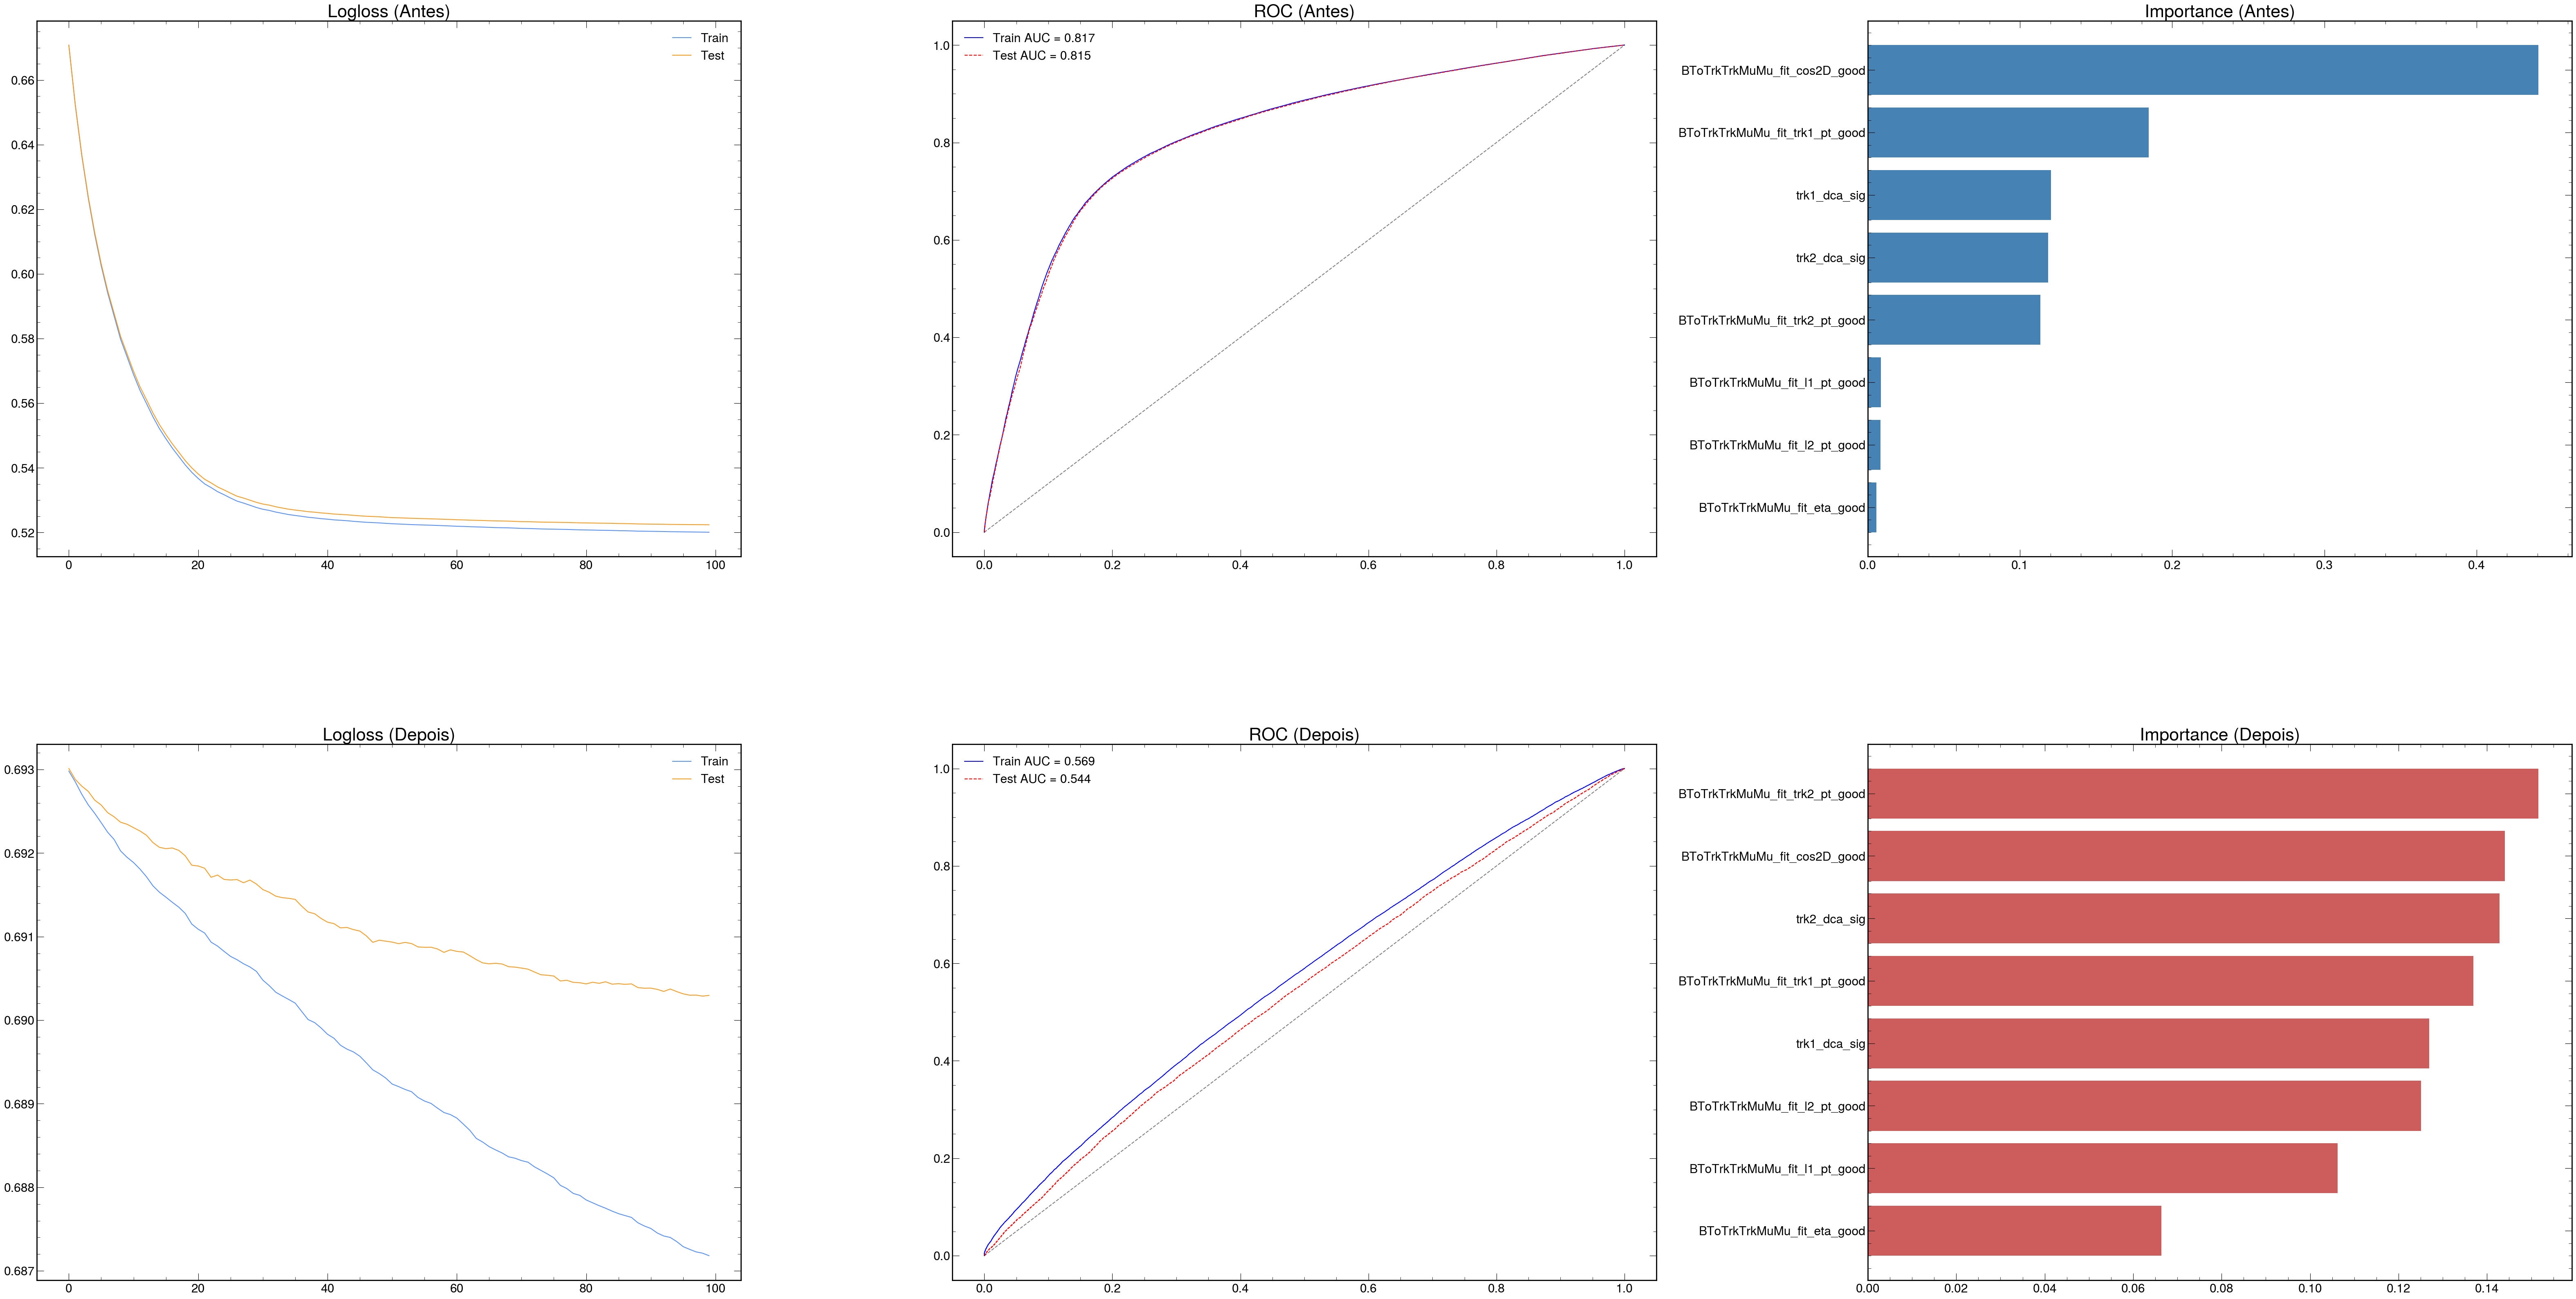

In [21]:
fig, axs = plt.subplots(2, 3, figsize=(80, 40))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# ---- LINHA 1: ANTES Pesos ----
axs[0, 0].plot(results_antes['validation_0']['logloss'], label='Train')
axs[0, 0].plot(results_antes['validation_1']['logloss'], label='Test')
axs[0, 0].set_title('Logloss (Antes)'); axs[0, 0].legend()

axs[0, 1].plot(fpr_train_a, tpr_train_a, color='blue', label=f'Train AUC = {auc(fpr_train_a, tpr_train_a):.3f}')
axs[0, 1].plot(fpr_test_a, tpr_test_a, color='red', linestyle='--', label=f'Test AUC = {auc(fpr_test_a, tpr_test_a):.3f}')
axs[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5); axs[0, 1].set_title('ROC (Antes)'); axs[0, 1].legend()

idx_a = np.argsort(clf.feature_importances_)
axs[0, 2].barh(range(len(idx_a)), clf.feature_importances_[idx_a], color='steelblue')
axs[0, 2].set_yticks(range(len(idx_a))); axs[0, 2].set_yticklabels([features_final[i] for i in idx_a]); axs[0, 2].set_title('Importance (Antes)')

# ---- LINHA 2: DEPOIS Pesos ----
axs[1, 0].plot(results_closure['validation_0']['logloss'], label='Train')
axs[1, 0].plot(results_closure['validation_1']['logloss'], label='Test')
axs[1, 0].set_title('Logloss (Depois)'); axs[1, 0].legend()

axs[1, 1].plot(fpr_train_d, tpr_train_d, color='blue', label=f'Train AUC = {auc(fpr_train_d, tpr_train_d):.3f}')
axs[1, 1].plot(fpr_test_d, tpr_test_d, color='red', linestyle='--', label=f'Test AUC = {auc(fpr_test_d, tpr_test_d):.3f}')
axs[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5); axs[1, 1].set_title('ROC (Depois)'); axs[1, 1].legend()

idx_d = np.argsort(clf_closure.feature_importances_)
axs[1, 2].barh(range(len(idx_d)), clf_closure.feature_importances_[idx_d], color='indianred')
axs[1, 2].set_yticks(range(len(idx_d))); axs[1, 2].set_yticklabels([features_final[i] for i in idx_d]); axs[1, 2].set_title('Importance (Depois)')
plt.show()

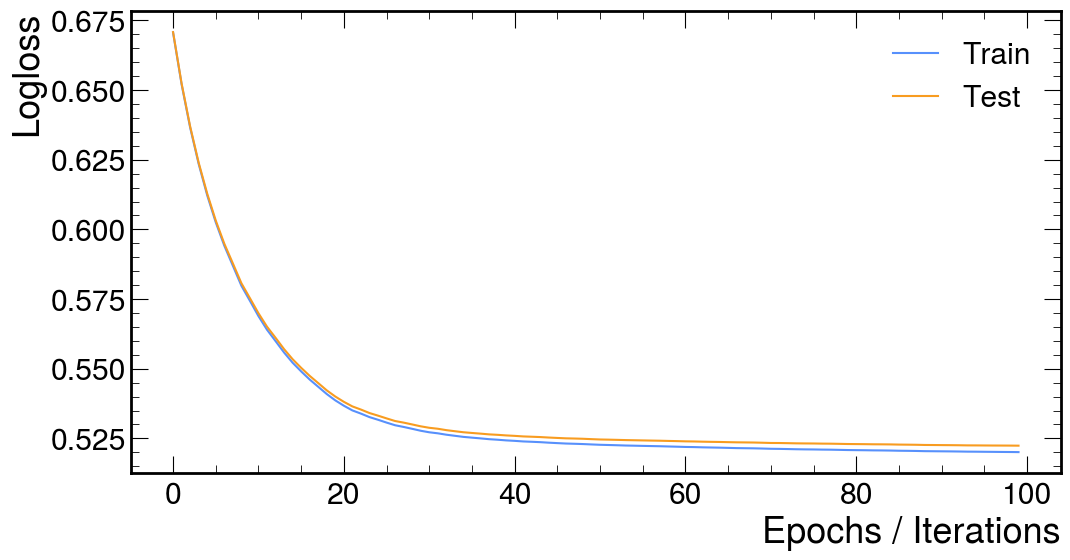

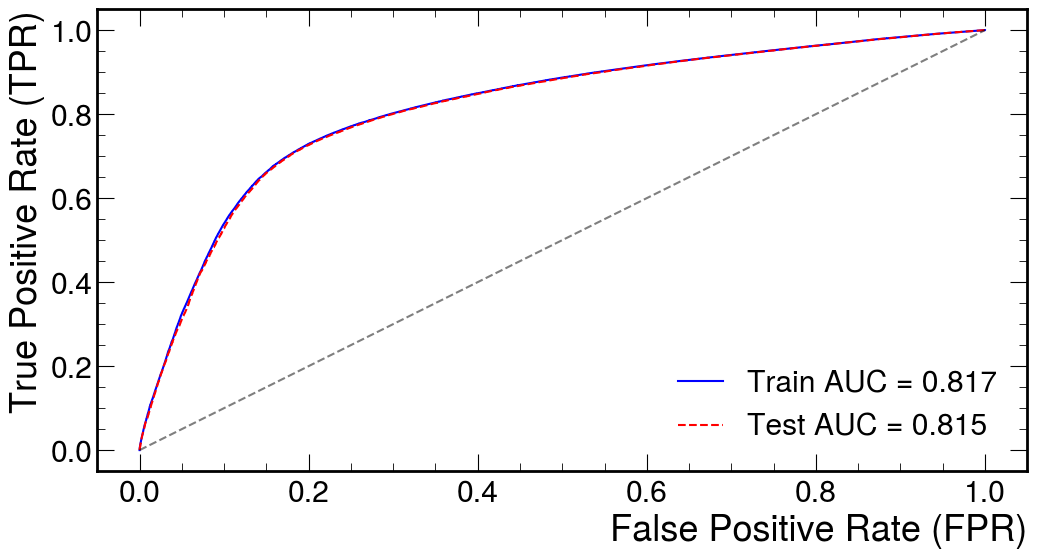

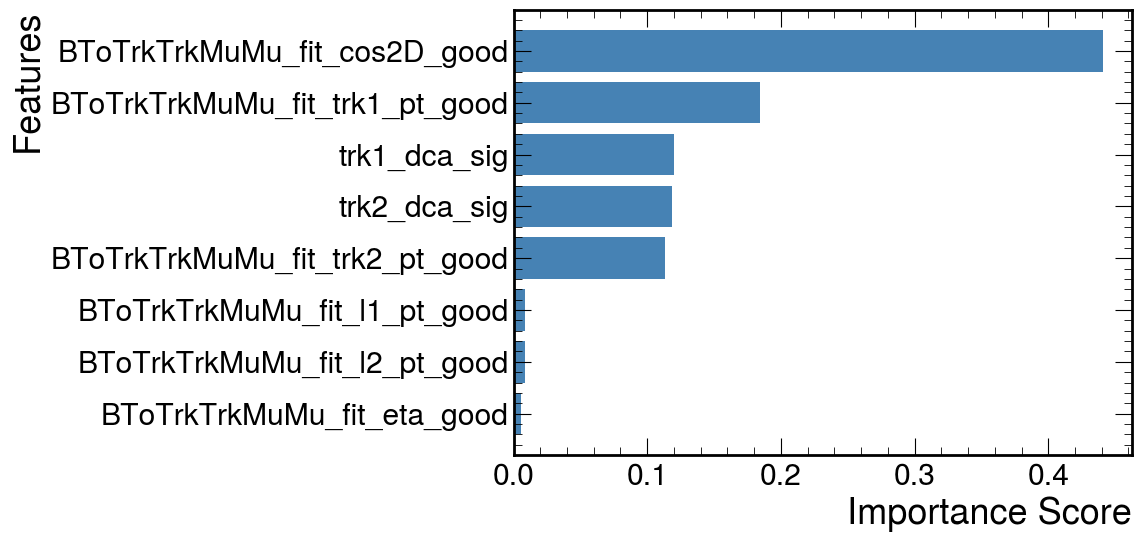

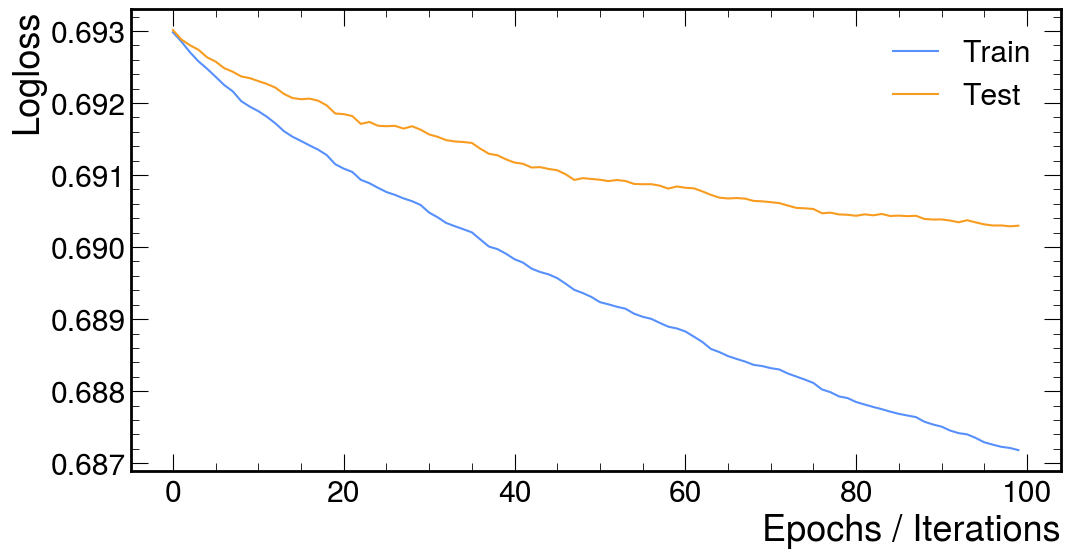

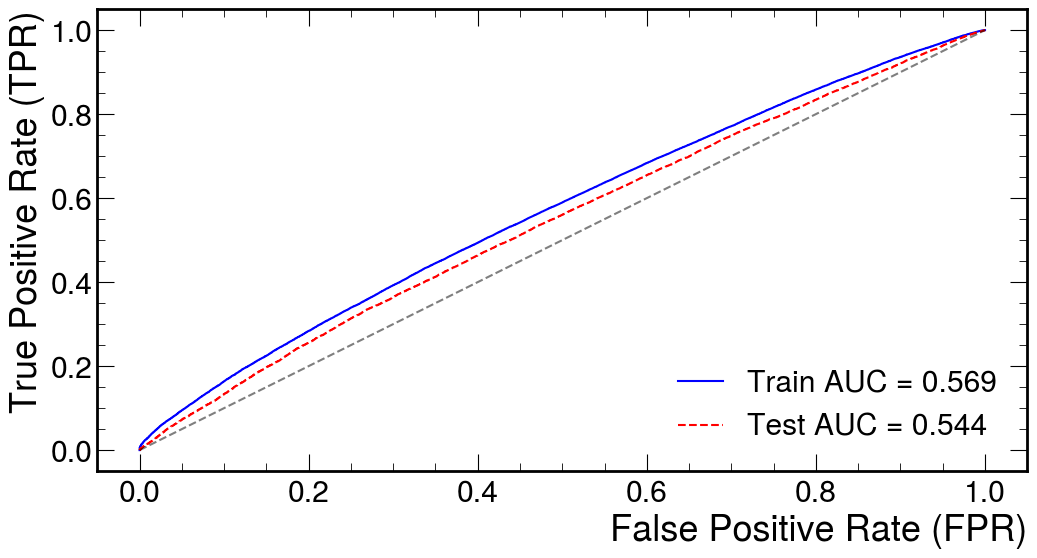

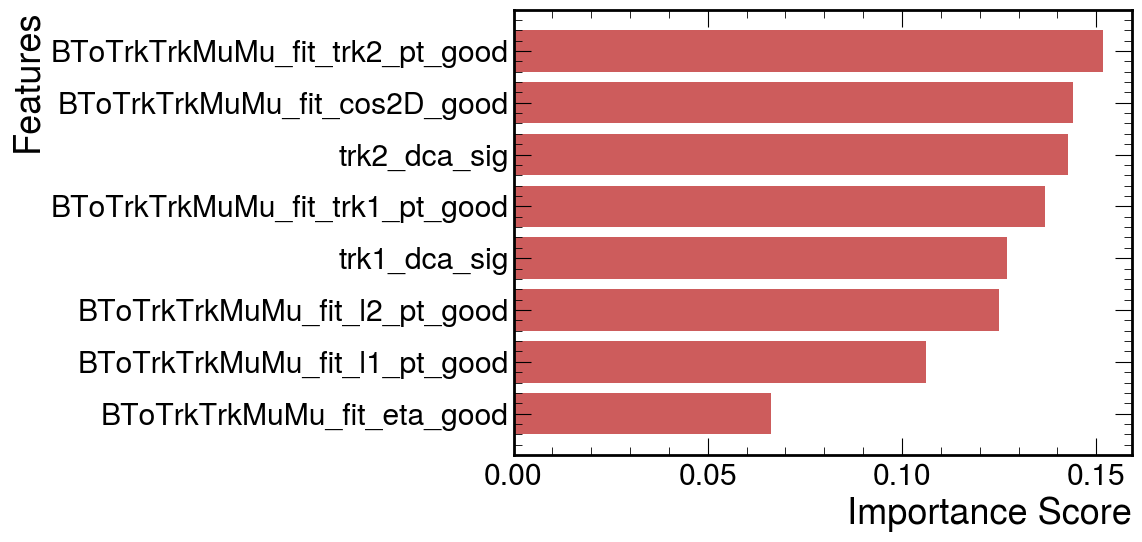

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import numpy as np

# Configuração de tamanho para cada figura individual
fig_size = (12, 6)

# ---- ANTES DOS PESOS ----

# 1. Logloss (Antes)
plt.figure(figsize=fig_size)
plt.plot(results_antes['validation_0']['logloss'], label='Train')
plt.plot(results_antes['validation_1']['logloss'], label='Test')
plt.xlabel('Epochs / Iterations')
plt.ylabel('Logloss')
plt.legend()
plt.show()

# 2. ROC Curve (Antes)
plt.figure(figsize=fig_size)
plt.plot(fpr_train_a, tpr_train_a, color='blue', label=f'Train AUC = {auc(fpr_train_a, tpr_train_a):.3f}')
plt.plot(fpr_test_a, tpr_test_a, color='red', linestyle='--', label=f'Test AUC = {auc(fpr_test_a, tpr_test_a):.3f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.show()

# 3. Feature Importance (Antes)
plt.figure(figsize=fig_size)
idx_a = np.argsort(clf.feature_importances_)
plt.barh(range(len(idx_a)), clf.feature_importances_[idx_a], color='steelblue')
plt.yticks(range(len(idx_a)), [features_final[i] for i in idx_a])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout() # Garante que os nomes das features não sejam cortados
plt.show()

# ---- DEPOIS DOS PESOS ----

# 4. Logloss (Depois)
plt.figure(figsize=fig_size)
plt.plot(results_closure['validation_0']['logloss'], label='Train')
plt.plot(results_closure['validation_1']['logloss'], label='Test')
plt.xlabel('Epochs / Iterations')
plt.ylabel('Logloss')
plt.legend()
plt.show()

# 5. ROC Curve (Depois)
plt.figure(figsize=fig_size)
plt.plot(fpr_train_d, tpr_train_d, color='blue', label=f'Train AUC = {auc(fpr_train_d, tpr_train_d):.3f}')
plt.plot(fpr_test_d, tpr_test_d, color='red', linestyle='--', label=f'Test AUC = {auc(fpr_test_d, tpr_test_d):.3f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.show()

# 6. Feature Importance (Depois)
plt.figure(figsize=fig_size)
idx_d = np.argsort(clf_closure.feature_importances_)
plt.barh(range(len(idx_d)), clf_closure.feature_importances_[idx_d], color='indianred')
plt.yticks(range(len(idx_d)), [features_final[i] for i in idx_d])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

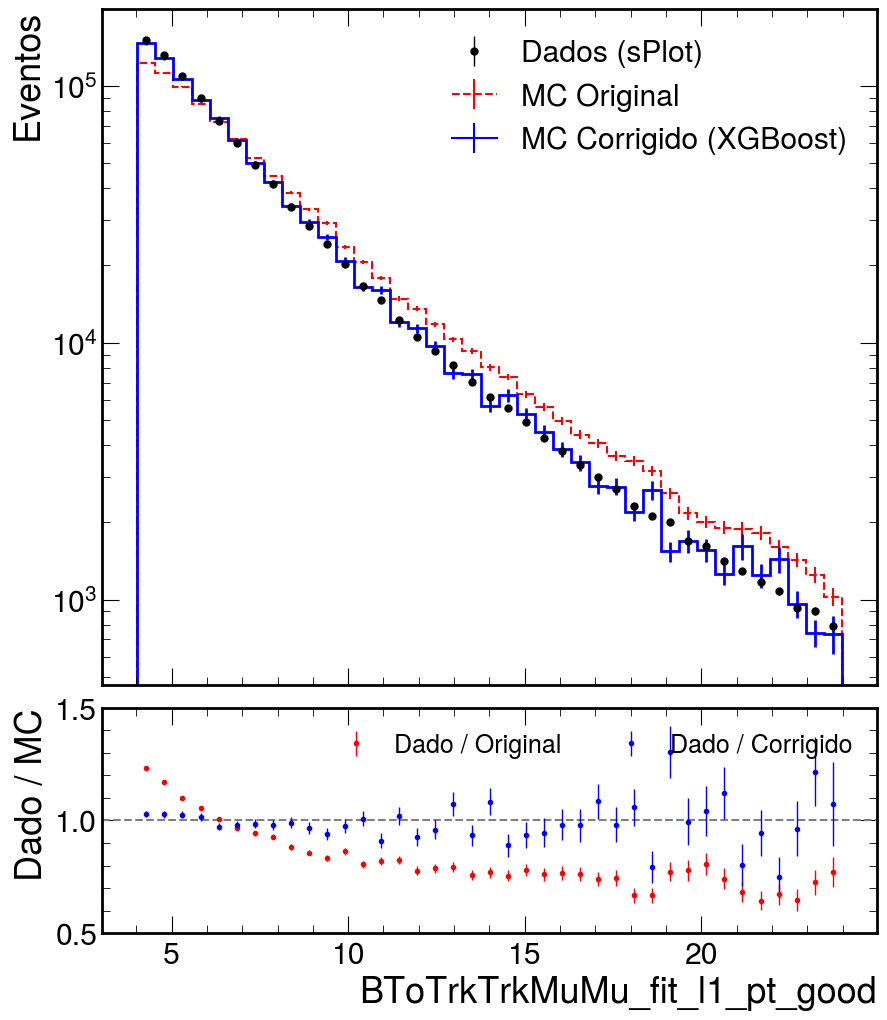

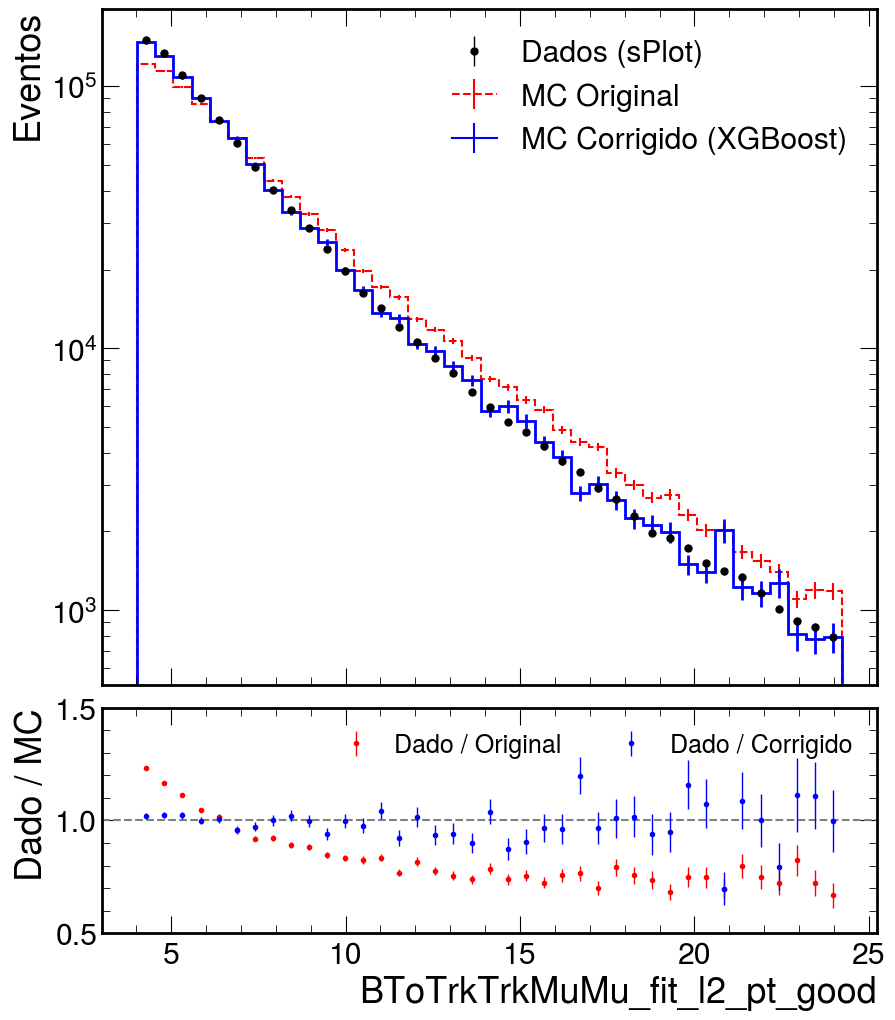

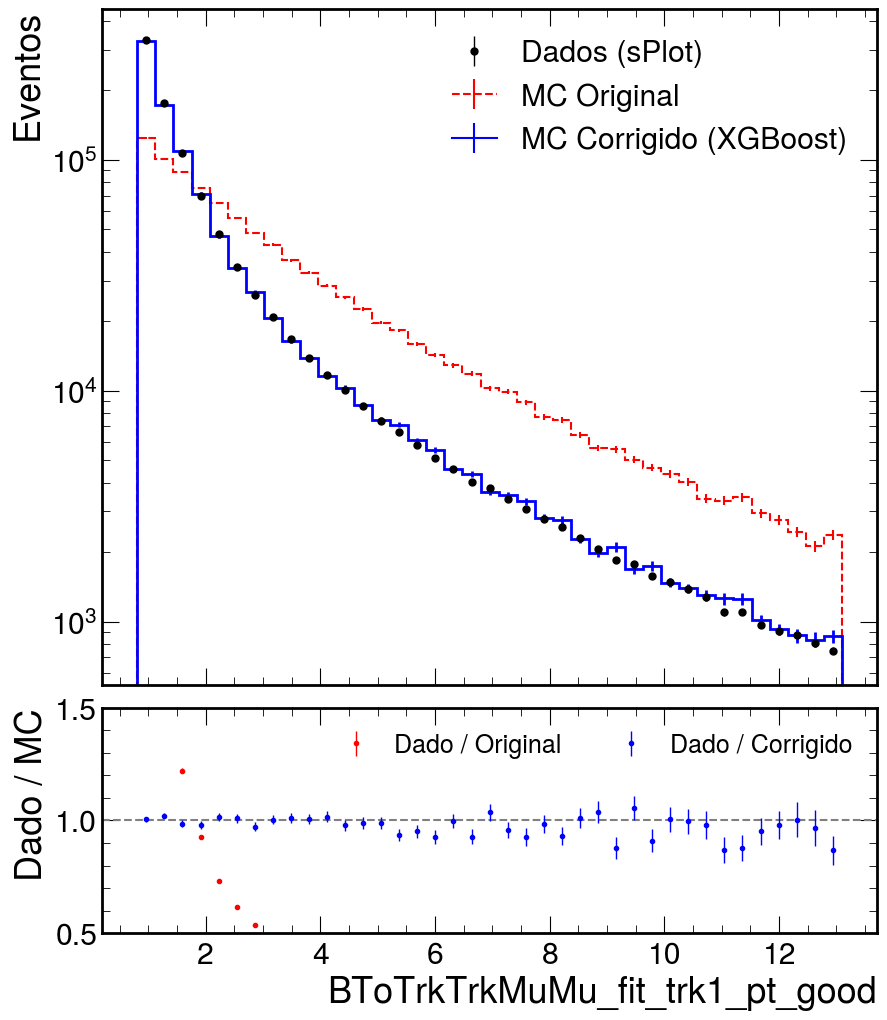

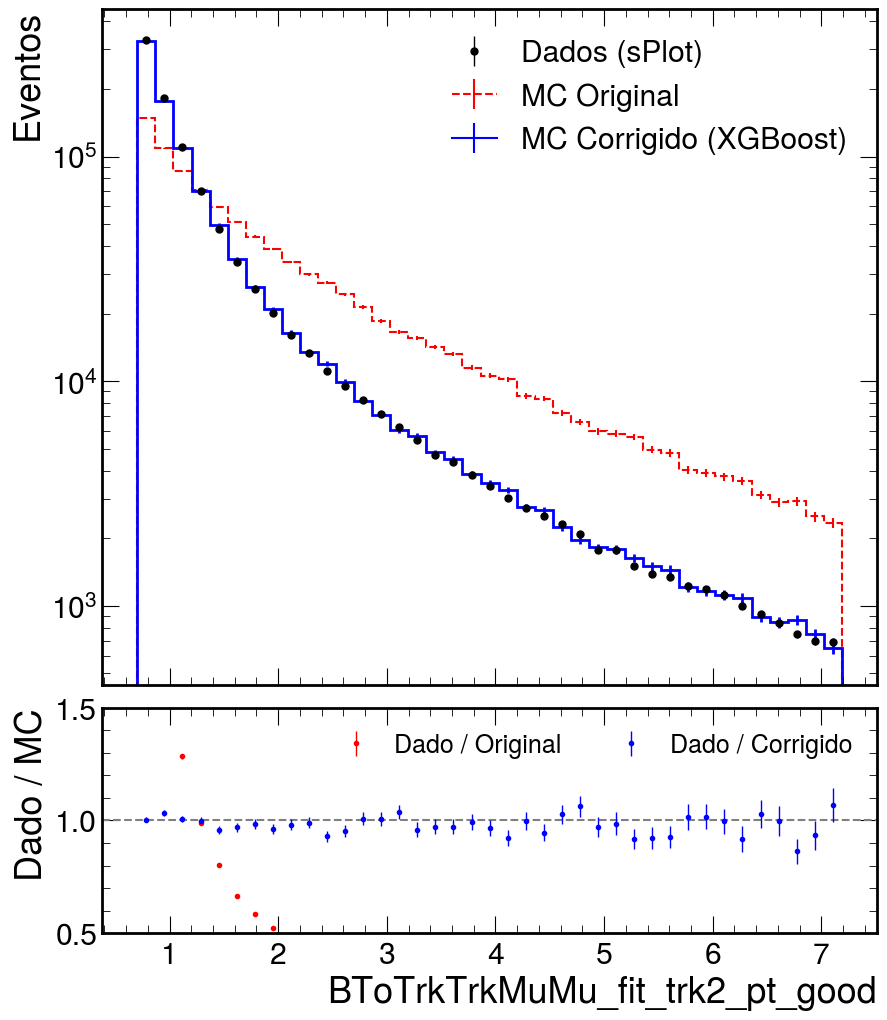

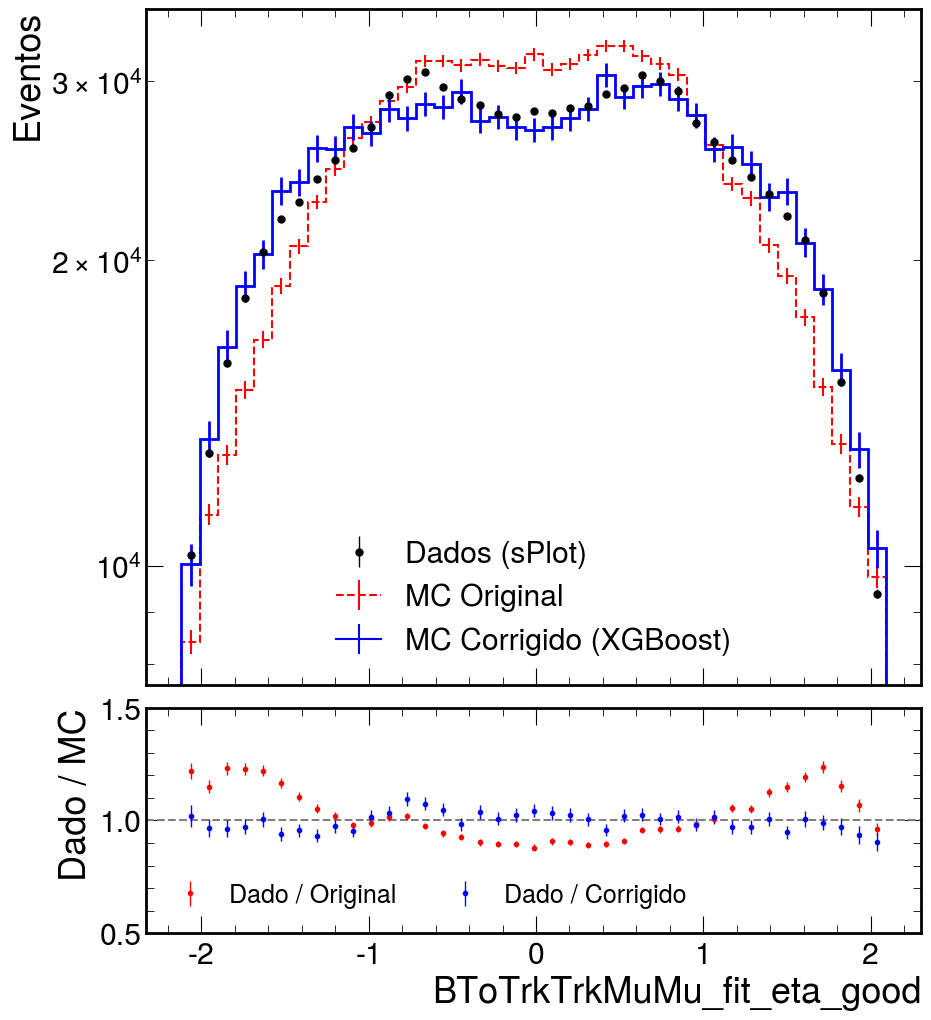

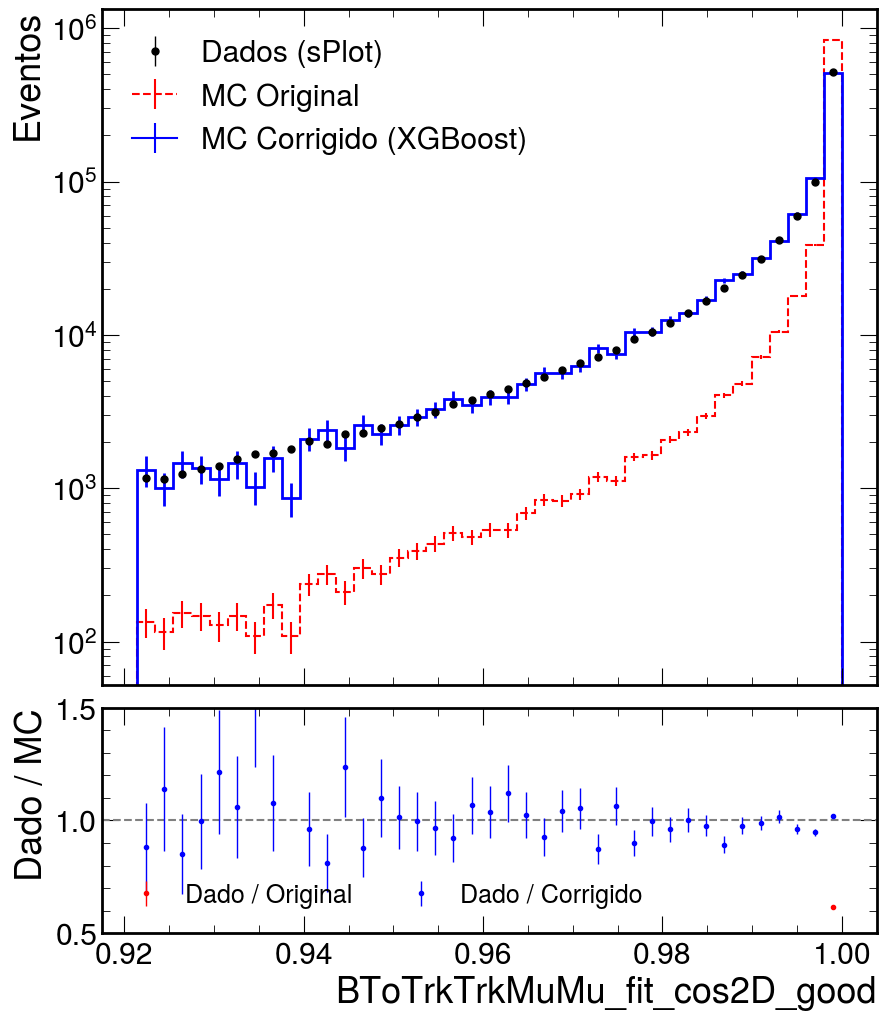

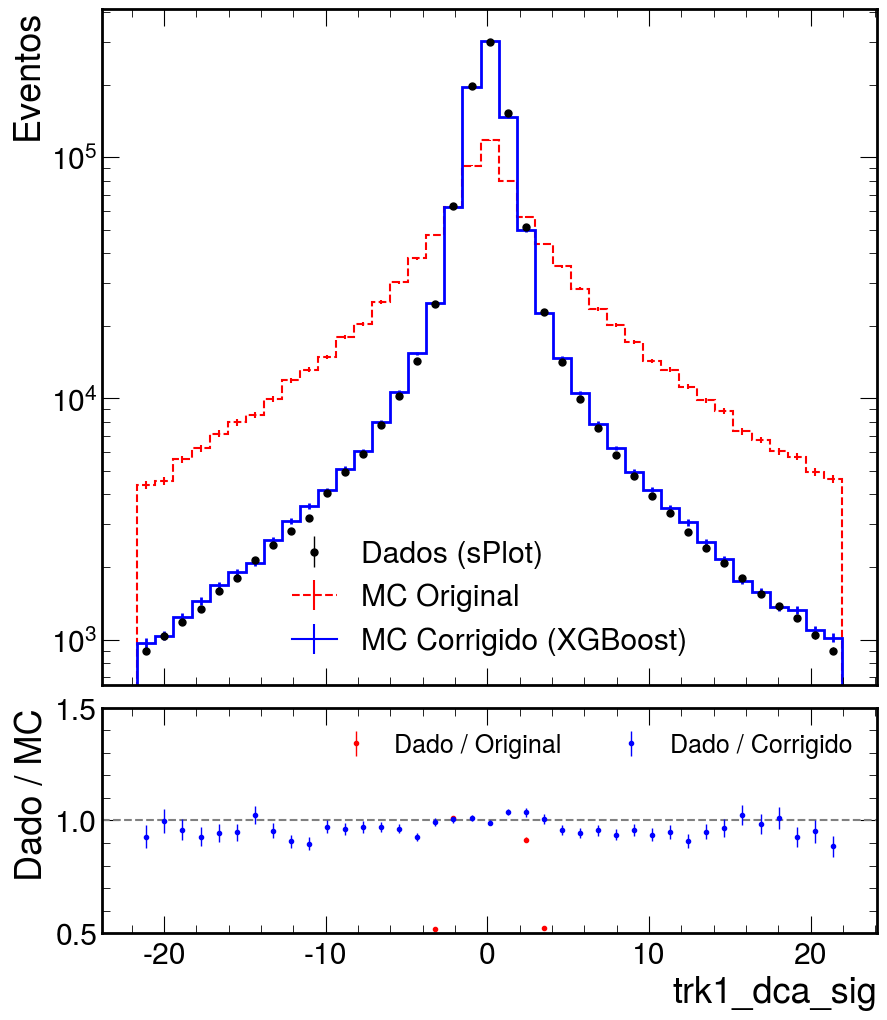

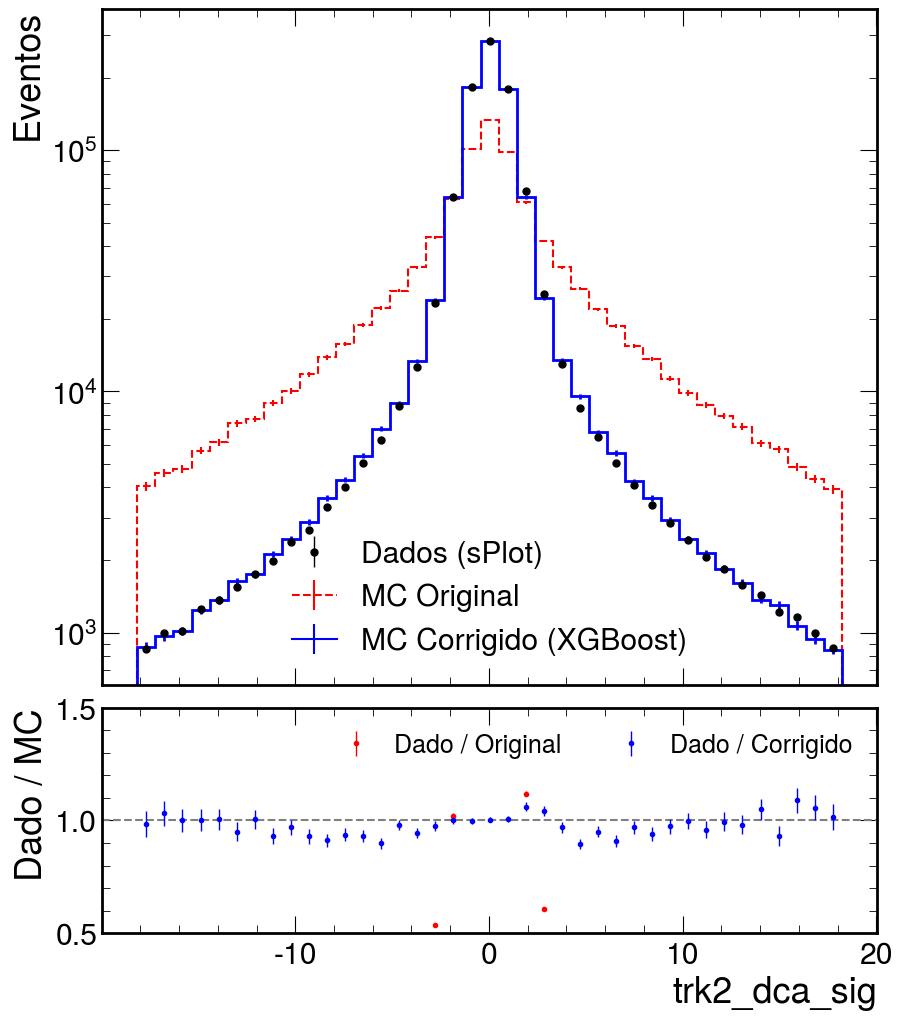

In [35]:
def plot_all_branches(df_data, df_mc, features):
    for var in features:
        min_v, max_v = np.percentile(df_data[var], [1, 99])
        bins = np.linspace(min_v, max_v, 40)
        fig, (ax, rax) = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}, sharex=True)
        
        # Histogramas
        h_dat, _ = np.histogram(df_data[var], bins=bins, weights=df_data['sweight_sig'])
        h_dat_err = np.sqrt(np.histogram(df_data[var], bins=bins, weights=df_data['sweight_sig']**2)[0])
        h_raw_v, _ = np.histogram(df_mc[var], bins=bins)
        h_raw_err = np.sqrt(h_raw_v)
        h_cor, _ = np.histogram(df_mc[var], bins=bins, weights=df_mc['bdt_weight'])
        h_cor_err = np.sqrt(np.histogram(df_mc[var], bins=bins, weights=df_mc['bdt_weight']**2)[0])

        s_raw = h_dat.sum() / h_raw_v.sum(); s_cor = h_dat.sum() / h_cor.sum()
        
        # Plot Superior
        hep.histplot(h_dat, bins=bins, yerr=h_dat_err, label='Dados (sPlot)', ax=ax, histtype='errorbar', color='black')
        hep.histplot(h_raw_v * s_raw, bins=bins, yerr=h_raw_err * s_raw, label='MC Original', ax=ax, color='red', linestyle='--')
        hep.histplot(h_cor * s_cor, bins=bins, yerr=h_cor_err * s_cor, label='MC Corrigido (XGBoost)', ax=ax, color='blue', lw=2)
        ax.set_yscale('log'); ax.set_ylabel("Eventos"); ax.legend()

        # Ratio Plot Duplo
        with np.errstate(divide='ignore', invalid='ignore'):
            r_raw = h_dat / (h_raw_v * s_raw)
            e_raw = r_raw * np.sqrt((h_dat_err/h_dat)**2 + (h_raw_err/h_raw_v)**2)
            r_cor = h_dat / (h_cor * s_cor)
            e_cor = r_cor * np.sqrt((h_dat_err/h_dat)**2 + (h_cor_err/h_cor)**2)
            for e in [e_raw, e_cor]: e[~np.isfinite(e)] = 0

        rax.axhline(1, color='gray', linestyle='--')
        hep.histplot(r_raw, bins=bins, yerr=e_raw, ax=rax, color='red', histtype='errorbar', marker='o', markersize=3, label='Dado / Original')
        hep.histplot(r_cor, bins=bins, yerr=e_cor, ax=rax, color='blue', histtype='errorbar', marker='o', markersize=3, label='Dado / Corrigido')
        
        rax.set_ylim(0.5, 1.5); rax.set_ylabel("Dado / MC"); rax.set_xlabel(var); rax.legend(fontsize='x-small', ncol=2)
        plt.show()

plot_all_branches(df_data_bdt, df_mc_bdt, features_final)

In [25]:
model_path = "model_reweighting_jpsi.joblib"
joblib.dump(clf, model_path)

['model_reweighting_jpsi.joblib']